In [1]:
## 1. Clone the DocShield-AI Repository

!rm -rf /content/docshield-ai
!git clone https://github.com/Raghavtripathii/docshield-ai.git /content/docshield-ai

%cd /content/docshield-ai

print("Repository setup: COMPLETE")

Cloning into '/content/docshield-ai'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 131 (delta 58), reused 89 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 779.55 KiB | 25.15 MiB/s, done.
Resolving deltas: 100% (58/58), done.
/content/docshield-ai
Repository setup: COMPLETE


In [2]:
## 2. Install the Required ML and Evaluation Dependencies

!pip install -q -r requirements.txt

print("Dependencies: INSTALLED")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.4 MB/s eta 0:00:00
Dependencies: INSTALLED


In [3]:
## 3. Verify the Colab GPU Environment

import sys
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

assert torch.cuda.is_available(), "GPU runtime is not available."

print("GPU:", torch.cuda.get_device_name(0))
print("\nGPU environment: READY")

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

GPU environment: READY


In [4]:
## 4. Load the Project Configuration and FUNSD Dataset

from src.config import CONFIG
from src.data import (
    load_funsd,
    validate_columns,
)
from src.labels import get_label_list

dataset = load_funsd()
validate_columns(dataset)

# IMPORTANT:
# get_label_list() in this repository requires the dataset.
label_list = get_label_list(dataset)

print("Dataset:", dataset)
print("\nLabels:", label_list)
print("Number of labels:", len(label_list))

print("\nTrain documents:", len(dataset["train"]))
print("Test documents:", len(dataset["test"]))

assert len(dataset["train"]) == 149
assert len(dataset["test"]) == 50
assert len(label_list) == 7

print("\nDataset setup: PASSED")

README.md:   0%|          | 0.00/755 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 12.3MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 4.38MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/149 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset: DatasetDict({
    train: Dataset({
        features: ['id', 'words', 'bboxes', 'ner_tags', 'image'],
        num_rows: 149
    })
    test: Dataset({
        features: ['id', 'words', 'bboxes', 'ner_tags', 'image'],
        num_rows: 50
    })
})

Labels: ['O', 'B-HEADER', 'I-HEADER', 'B-QUESTION', 'I-QUESTION', 'B-ANSWER', 'I-ANSWER']
Number of labels: 7

Train documents: 149
Test documents: 50

Dataset setup: PASSED


In [9]:
## 5. Restore the Fine-Tuned LayoutLMv3 Checkpoint

from pathlib import Path
import zipfile
import shutil

zip_path = Path("/content/docshield-ai/docshield-layoutlmv3-baseline.zip")

assert zip_path.exists(), (
    f"Checkpoint ZIP not found:\n{zip_path}"
)

MODEL_DIR = Path("/content/docshield-layoutlmv3-baseline")

# Remove any previous extraction
if MODEL_DIR.exists():
    shutil.rmtree(MODEL_DIR)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Extract checkpoint
with zipfile.ZipFile(zip_path, "r") as archive:
    archive.extractall(MODEL_DIR)

# Validate checkpoint
required_files = {
    "config.json",
    "model.safetensors",
    "processor_config.json",
    "tokenizer.json",
    "tokenizer_config.json",
}

restored_files = {
    path.name
    for path in MODEL_DIR.iterdir()
    if path.is_file()
}

missing_files = required_files - restored_files

assert not missing_files, (
    f"Checkpoint incomplete. Missing: {sorted(missing_files)}"
)

print("Fine-tuned checkpoint: RESTORED")
print("Checkpoint path:", MODEL_DIR)

print("\nCheckpoint files:")
for file in sorted(restored_files):
    print(" -", file)

print("\nCheckpoint validation: PASSED")

Fine-tuned checkpoint: RESTORED
Checkpoint path: /content/docshield-layoutlmv3-baseline

Checkpoint files:
 - config.json
 - model.safetensors
 - processor_config.json
 - tokenizer.json
 - tokenizer_config.json
 - training_args.bin

Checkpoint validation: PASSED


In [10]:
## 6. Load the LayoutLMv3 Processor

from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(
    MODEL_DIR,
    apply_ocr=False,
)

print("Processor:", type(processor).__name__)
print("OCR enabled:", processor.image_processor.apply_ocr)

assert processor.image_processor.apply_ocr is False

print("\nProcessor loading: PASSED")

Processor: LayoutLMv3Processor
OCR enabled: False

Processor loading: PASSED


In [11]:
## 7. Load the Fine-Tuned LayoutLMv3 Model

from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_DIR
)

model = model.to("cuda")
model.eval()

print("Model:", type(model).__name__)
print("Number of labels:", model.config.num_labels)
print("Device:", next(model.parameters()).device)

assert model.config.num_labels == len(label_list)

print("\nFine-tuned model loading: PASSED")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Model: LayoutLMv3ForTokenClassification
Number of labels: 7
Device: cuda:0

Fine-tuned model loading: PASSED


In [12]:
## 8. Encode the FUNSD Test Split for Error Analysis

from src.preprocessing import (
    encode_document,
    validate_encoding,
)

def encode_example(example):
    encoding = encode_document(
        processor=processor,
        image=example["image"],
        words=example["words"],
        boxes=example["bboxes"],
        labels=example["ner_tags"],
    )

    validate_encoding(encoding)

    return {
        key: value.squeeze(0)
        for key, value in encoding.items()
    }


eval_dataset = dataset["test"].map(
    encode_example,
    remove_columns=dataset["test"].column_names,
)

assert len(eval_dataset) == 50

print("Evaluation rows:", len(eval_dataset))
print("Encoded columns:", eval_dataset.column_names)

print("\nEvaluation encoding: PASSED")

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Evaluation rows: 50
Encoded columns: ['input_ids', 'attention_mask', 'bbox', 'labels', 'pixel_values']

Evaluation encoding: PASSED


In [13]:
## 9. Validate the Encoded Tensor Shapes

import numpy as np

sample = eval_dataset[0]

expected_shapes = {
    "input_ids": (512,),
    "attention_mask": (512,),
    "bbox": (512, 4),
    "labels": (512,),
    "pixel_values": (3, 224, 224),
}

for key, expected_shape in expected_shapes.items():
    actual_shape = np.asarray(sample[key]).shape

    print(
        f"{key:15s}",
        "->",
        actual_shape,
    )

    assert actual_shape == expected_shape, (
        f"{key}: expected {expected_shape}, "
        f"received {actual_shape}"
    )

print("\nEncoded tensor validation: PASSED")

input_ids       -> (512,)
attention_mask  -> (512,)
bbox            -> (512, 4)
labels          -> (512,)
pixel_values    -> (3, 224, 224)

Encoded tensor validation: PASSED


In [14]:
## 10. Configure the Evaluation Predictor

from transformers import (
    Trainer,
    TrainingArguments,
)

prediction_args = TrainingArguments(
    output_dir="/content/docshield-error-analysis",
    per_device_eval_batch_size=4,
    report_to="none",
)

evaluator = Trainer(
    model=model,
    args=prediction_args,
)

print("Evaluation batch size:", 4)
print("Predictor configuration: READY")

Evaluation batch size: 4
Predictor configuration: READY


In [15]:
## 11. Generate Predictions from the Fine-Tuned Model

prediction_output = evaluator.predict(
    eval_dataset
)

logits = prediction_output.predictions
label_ids = prediction_output.label_ids

print("Logits shape:", logits.shape)
print("Labels shape:", label_ids.shape)

assert logits.shape[:2] == label_ids.shape
assert logits.shape[2] == len(label_list)

print("\nBaseline predictions: GENERATED")

Logits shape: (50, 512, 7)
Labels shape: (50, 512)

Baseline predictions: GENERATED


In [16]:
## 12. Convert Model Outputs into Predictions and Confidence Scores

import numpy as np
import torch

predicted_ids = np.argmax(
    logits,
    axis=-1,
)

probabilities = torch.softmax(
    torch.tensor(logits),
    dim=-1,
).numpy()

confidence_scores = np.max(
    probabilities,
    axis=-1,
)

print("Predicted IDs:", predicted_ids.shape)
print("Confidence scores:", confidence_scores.shape)

assert predicted_ids.shape == label_ids.shape
assert confidence_scores.shape == label_ids.shape

print("\nPrediction conversion: PASSED")

Predicted IDs: (50, 512)
Confidence scores: (50, 512)

Prediction conversion: PASSED


In [17]:
## 13. Extract Valid Labeled Tokens for Error Analysis

valid_mask = label_ids != -100

flat_true_ids = label_ids[valid_mask]
flat_pred_ids = predicted_ids[valid_mask]
flat_confidence = confidence_scores[valid_mask]

flat_true_labels = [
    label_list[int(label_id)]
    for label_id in flat_true_ids
]

flat_pred_labels = [
    label_list[int(label_id)]
    for label_id in flat_pred_ids
]

print("Valid labeled tokens:", len(flat_true_ids))
print("Correct predictions:", int(
    np.sum(flat_true_ids == flat_pred_ids)
))
print("Incorrect predictions:", int(
    np.sum(flat_true_ids != flat_pred_ids)
))

assert len(flat_true_ids) > 0

print("\nValid token extraction: PASSED")

Valid labeled tokens: 8356
Correct predictions: 6666
Incorrect predictions: 1690

Valid token extraction: PASSED


In [18]:
## 14. Measure the Overall Token-Level Error Rate

correct_mask = (
    flat_true_ids == flat_pred_ids
)

incorrect_mask = ~correct_mask

accuracy = correct_mask.mean()
error_rate = incorrect_mask.mean()

print(f"Token accuracy : {accuracy:.6f}")
print(f"Token error rate: {error_rate:.6f}")

print(
    "Misclassified tokens:",
    int(incorrect_mask.sum()),
)

assert 0.0 <= accuracy <= 1.0
assert 0.0 <= error_rate <= 1.0

print("\nToken-level error analysis: COMPLETE")

Token accuracy : 0.797750
Token error rate: 0.202250
Misclassified tokens: 1690

Token-level error analysis: COMPLETE


In [19]:
## 15. Build the Token-Level Confusion Matrix

from sklearn.metrics import confusion_matrix
import pandas as pd

label_ids_order = list(
    range(len(label_list))
)

cm = confusion_matrix(
    flat_true_ids,
    flat_pred_ids,
    labels=label_ids_order,
)

confusion_df = pd.DataFrame(
    cm,
    index=label_list,
    columns=label_list,
)

print("Rows = true labels")
print("Columns = predicted labels")
print()

display(confusion_df)

assert cm.shape == (
    len(label_list),
    len(label_list),
)

print("\nConfusion matrix: COMPLETE")

Rows = true labels
Columns = predicted labels



,O,B-HEADER,I-HEADER,B-QUESTION,I-QUESTION,B-ANSWER,I-ANSWER
O,1827,18,111,28,99,25,123
B-HEADER,6,57,2,47,1,6,0
I-HEADER,48,6,142,2,46,2,9
B-QUESTION,31,10,2,935,36,27,8
I-QUESTION,233,0,31,15,1072,0,72
B-ANSWER,29,1,0,34,4,716,21
I-ANSWER,413,0,1,10,67,66,1917



Confusion matrix: COMPLETE


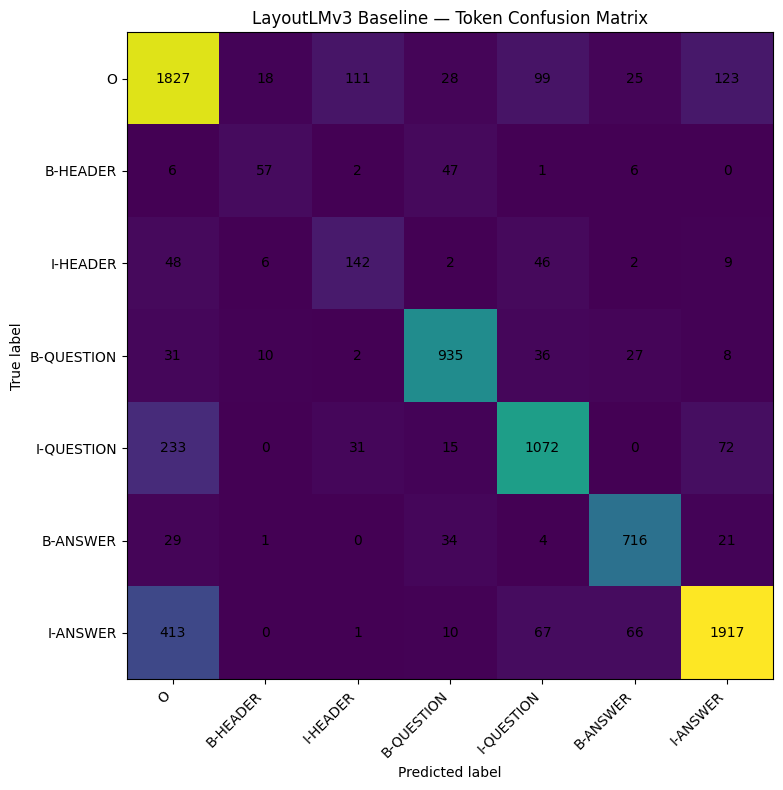

In [20]:
## 16. Visualize the Baseline Confusion Matrix

import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(cm)

ax.set_xticks(
    range(len(label_list))
)

ax.set_yticks(
    range(len(label_list))
)

ax.set_xticklabels(
    label_list,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    label_list
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    "LayoutLMv3 Baseline — Token Confusion Matrix"
)

for i in range(len(label_list)):
    for j in range(len(label_list)):
        ax.text(
            j,
            i,
            int(cm[i, j]),
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()

In [21]:
## 17. Identify the Most Frequent Misclassification Patterns

confusion_records = []

for true_id in range(len(label_list)):
    for pred_id in range(len(label_list)):

        if true_id == pred_id:
            continue

        count = int(
            cm[true_id, pred_id]
        )

        if count > 0:
            confusion_records.append({
                "true_label": label_list[true_id],
                "predicted_label": label_list[pred_id],
                "count": count,
            })

confusion_records = sorted(
    confusion_records,
    key=lambda item: item["count"],
    reverse=True,
)

confusion_patterns_df = pd.DataFrame(
    confusion_records
)

print("Top baseline confusion patterns:")
display(
    confusion_patterns_df.head(15)
)

Top baseline confusion patterns:


,true_label,predicted_label,count
0,I-ANSWER,O,413
1,I-QUESTION,O,233
2,O,I-ANSWER,123
3,O,I-HEADER,111
4,O,I-QUESTION,99
5,I-QUESTION,I-ANSWER,72
6,I-ANSWER,I-QUESTION,67
7,I-ANSWER,B-ANSWER,66
8,I-HEADER,O,48
9,B-HEADER,B-QUESTION,47


In [22]:
## 18. Measure Error Rates for Every BIO Label

label_error_records = []

for label_id, label_name in enumerate(label_list):

    mask = (
        flat_true_ids == label_id
    )

    support = int(mask.sum())

    if support == 0:
        continue

    correct = int(
        (
            flat_pred_ids[mask]
            == label_id
        ).sum()
    )

    errors = support - correct

    label_error_records.append({
        "label": label_name,
        "support": support,
        "correct": correct,
        "errors": errors,
        "error_rate": errors / support,
    })

label_error_df = pd.DataFrame(
    label_error_records
).sort_values(
    "error_rate",
    ascending=False,
)

display(label_error_df)

print(
    "\nWorst BIO label:",
    label_error_df.iloc[0]["label"],
)

,label,support,correct,errors,error_rate
1,B-HEADER,119,57,62,0.521008
2,I-HEADER,255,142,113,0.443137
4,I-QUESTION,1423,1072,351,0.246662
6,I-ANSWER,2474,1917,557,0.225141
0,O,2231,1827,404,0.181085
5,B-ANSWER,805,716,89,0.110559
3,B-QUESTION,1049,935,114,0.108675



Worst BIO label: B-HEADER


In [23]:
## 19. Compare Confidence on Correct and Incorrect Predictions

correct_confidence = (
    flat_confidence[correct_mask]
)

incorrect_confidence = (
    flat_confidence[incorrect_mask]
)

print(
    "Mean confidence — correct:",
    f"{correct_confidence.mean():.6f}",
)

print(
    "Mean confidence — incorrect:",
    f"{incorrect_confidence.mean():.6f}",
)

print(
    "Median confidence — correct:",
    f"{np.median(correct_confidence):.6f}",
)

print(
    "Median confidence — incorrect:",
    f"{np.median(incorrect_confidence):.6f}",
)

print(
    "\nConfidence/error relationship: ANALYZED"
)

Mean confidence — correct: 0.855204
Mean confidence — incorrect: 0.696432
Median confidence — correct: 0.903105
Median confidence — incorrect: 0.705550

Confidence/error relationship: ANALYZED


In [24]:
## 20. Analyze Low-Confidence Token Predictions

thresholds = [
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
]

confidence_analysis = []

for threshold in thresholds:

    mask = (
        flat_confidence < threshold
    )

    count = int(mask.sum())

    if count == 0:
        error_rate_at_threshold = 0.0
    else:
        error_rate_at_threshold = float(
            (
                flat_true_ids[mask]
                != flat_pred_ids[mask]
            ).mean()
        )

    confidence_analysis.append({
        "confidence_below": threshold,
        "token_count": count,
        "error_rate": error_rate_at_threshold,
    })

confidence_df = pd.DataFrame(
    confidence_analysis
)

display(confidence_df)

print(
    "\nLow-confidence behavior: ANALYZED"
)

,confidence_below,token_count,error_rate
0,0.5,432,0.599537
1,0.6,995,0.561809
2,0.7,1638,0.506716
3,0.8,2628,0.427321
4,0.9,4689,0.309874



Low-confidence behavior: ANALYZED


In [25]:
## 21. Measure Error Rates Across Individual FUNSD Documents

document_records = []

for document_index in range(
    len(eval_dataset)
):

    document_labels = (
        label_ids[document_index]
    )

    document_predictions = (
        predicted_ids[document_index]
    )

    mask = (
        document_labels != -100
    )

    valid_labels = (
        document_labels[mask]
    )

    valid_predictions = (
        document_predictions[mask]
    )

    token_count = len(
        valid_labels
    )

    error_count = int(
        (
            valid_labels
            != valid_predictions
        ).sum()
    )

    error_rate = (
        error_count / token_count
        if token_count
        else 0.0
    )

    document_records.append({
        "document_index": document_index,
        "token_count": token_count,
        "errors": error_count,
        "error_rate": error_rate,
    })

document_error_df = pd.DataFrame(
    document_records
).sort_values(
    "error_rate",
    ascending=False,
)

display(
    document_error_df.head(10)
)

print(
    "\nDocument-level errors: ANALYZED"
)

,document_index,token_count,errors,error_rate
0,0,223,142,0.636771
33,33,80,44,0.550000
30,30,75,35,0.466667
45,45,240,102,0.425000
1,1,167,70,0.419162
21,21,236,97,0.411017
15,15,204,79,0.387255
24,24,80,27,0.337500
3,3,222,74,0.333333
4,4,108,31,0.287037



Document-level errors: ANALYZED


Correlation between labeled-token count and error rate:
0.239968


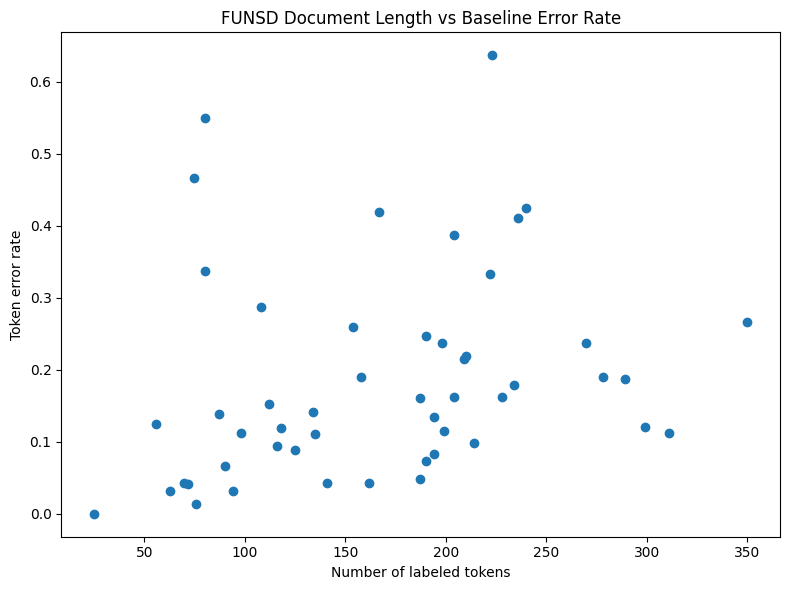


Document-length relationship: ANALYZED


In [26]:
## 22. Analyze Document Length Versus Error Rate

length_error_correlation = (
    document_error_df[
        ["token_count", "error_rate"]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Correlation between labeled-token count "
    "and error rate:"
)

print(
    f"{length_error_correlation:.6f}"
)

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    document_error_df["token_count"],
    document_error_df["error_rate"],
)

plt.xlabel(
    "Number of labeled tokens"
)

plt.ylabel(
    "Token error rate"
)

plt.title(
    "FUNSD Document Length vs Baseline Error Rate"
)

plt.tight_layout()
plt.show()

print(
    "\nDocument-length relationship: ANALYZED"
)

In [27]:
## 23. Investigate Potential Sequence Truncation

truncation_records = []

for document_index in range(
    len(eval_dataset)
):

    attention_mask = np.asarray(
        eval_dataset[
            document_index
        ]["attention_mask"]
    )

    active_tokens = int(
        attention_mask.sum()
    )

    reached_limit = (
        active_tokens >= 512
    )

    truncation_records.append({
        "document_index": document_index,
        "active_tokens": active_tokens,
        "reached_512_limit": reached_limit,
    })

truncation_df = pd.DataFrame(
    truncation_records
)

print(
    "Documents reaching 512-token limit:",
    int(
        truncation_df[
            "reached_512_limit"
        ].sum()
    ),
)

print(
    "Total evaluation documents:",
    len(truncation_df),
)

display(
    truncation_df.sort_values(
        "active_tokens",
        ascending=False,
    ).head(10)
)

print(
    "\nTruncation pressure: ANALYZED"
)

Documents reaching 512-token limit: 4
Total evaluation documents: 50


,document_index,active_tokens,reached_512_limit
44,44,512,True
45,45,512,True
47,47,512,True
49,49,512,True
16,16,480,False
48,48,473,False
7,7,412,False
35,35,409,False
46,46,406,False
6,6,374,False



Truncation pressure: ANALYZED


In [28]:
## 24. Compare Errors for Documents at the Sequence Limit

document_analysis_df = (
    pd.DataFrame(document_records)
    .merge(
        truncation_df,
        on="document_index",
    )
)

grouped_truncation = (
    document_analysis_df
    .groupby(
        "reached_512_limit"
    )["error_rate"]
    .agg([
        "count",
        "mean",
        "median",
    ])
)

display(grouped_truncation)

print(
    "\nSequence-limit error comparison: COMPLETE"
)

,count,mean,median
reached_512_limit,,,
False,46,0.179968,0.135976
True,4,0.267053,0.228181



Sequence-limit error comparison: COMPLETE


In [29]:
## 25. Identify Representative High-Error Documents

worst_documents = (
    document_analysis_df
    .sort_values(
        "error_rate",
        ascending=False,
    )
    .head(10)
)

display(worst_documents)

print(
    "\nHighest-error document indices:",
    worst_documents[
        "document_index"
    ].tolist(),
)

,document_index,token_count,errors,error_rate,active_tokens,reached_512_limit
0,0,223,142,0.636771,360,False
33,33,80,44,0.550000,175,False
30,30,75,35,0.466667,118,False
45,45,240,102,0.425000,512,True
1,1,167,70,0.419162,293,False
21,21,236,97,0.411017,354,False
15,15,204,79,0.387255,351,False
24,24,80,27,0.337500,147,False
3,3,222,74,0.333333,321,False
4,4,108,31,0.287037,240,False



Highest-error document indices: [0, 33, 30, 45, 1, 21, 15, 24, 3, 4]


In [30]:
## 26. Summarize the Baseline Error Analysis

worst_label_row = (
    label_error_df.iloc[0]
)

most_common_confusion = (
    confusion_patterns_df.iloc[0]
    if len(confusion_patterns_df)
    else None
)

summary = {
    "evaluation_documents":
        int(len(eval_dataset)),

    "valid_labeled_tokens":
        int(len(flat_true_ids)),

    "token_accuracy":
        float(accuracy),

    "token_error_rate":
        float(error_rate),

    "worst_bio_label":
        str(
            worst_label_row["label"]
        ),

    "worst_bio_label_error_rate":
        float(
            worst_label_row["error_rate"]
        ),

    "mean_correct_confidence":
        float(
            correct_confidence.mean()
        ),

    "mean_incorrect_confidence":
        float(
            incorrect_confidence.mean()
        ),

    "documents_at_512_limit":
        int(
            truncation_df[
                "reached_512_limit"
            ].sum()
        ),

    "length_error_correlation":
        float(
            length_error_correlation
        ),
}

if most_common_confusion is not None:
    summary[
        "most_common_confusion"
    ] = {
        "true_label":
            str(
                most_common_confusion[
                    "true_label"
                ]
            ),

        "predicted_label":
            str(
                most_common_confusion[
                    "predicted_label"
                ]
            ),

        "count":
            int(
                most_common_confusion[
                    "count"
                ]
            ),
    }

print("Baseline error-analysis summary:")

for key, value in summary.items():
    print(
        f"{key}: {value}"
    )

print(
    "\nBaseline error analysis: COMPLETE"
)

Baseline error-analysis summary:
evaluation_documents: 50
valid_labeled_tokens: 8356
token_accuracy: 0.7977501196744854
token_error_rate: 0.18685121107266436
worst_bio_label: B-HEADER
worst_bio_label_error_rate: 0.5210084033613446
mean_correct_confidence: 0.8552040457725525
mean_incorrect_confidence: 0.6964319348335266
documents_at_512_limit: 4
length_error_correlation: 0.23996793042802111
most_common_confusion: {'true_label': 'I-ANSWER', 'predicted_label': 'O', 'count': 413}

Baseline error analysis: COMPLETE
